In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as   mcolors
from datataking import search_datadict_miyamura
from scipy import interpolate
from Analysis import WaveformAnalysis, WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit
import time as T

cd = "CDK173"
data_path = f"D:\\K_Sunada\\result\\{cd}"

readout_lo_freq = 9.47
# target_freq = 10.3875

In [2]:
def fit_waveform(time, data, x0=[2e-3,460], get_center=False, curve='sech_0', **kwargs):
    if curve=='sech_0':
        func = lambda x: x[0]/np.cosh(kwargs['kappa']*(time-x[1]))
        cost_func = lambda x: np.linalg.norm(x[0]/np.cosh(kwargs['kappa']*(time-x[1])) - data)
    elif curve=="sech_1":
        func = lambda x: np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    elif curve=="sech_2":
        func = lambda x: np.abs(x[0]*((time-x[1])**2-(np.pi/2/const)**2/3)/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*((time-x[1])**2-(np.pi/2/const)**2/3)/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    elif curve=="sech_3":
        func = lambda x: np.abs(x[0]*((time-x[1])**3-(7*(time-x[1])*(np.pi/(2*const))**2/5))/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*((time-x[1])**3-(7*(time-x[1])*(np.pi/(2*const))**2/5))/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    
    best_x = optimize.minimize(cost_func, x0=x0,method='Nelder-Mead',)
    # print(best_x)
    # print(f"center:{best_x.x}")
    if get_center==True:
        return best_x.x, func(best_x.x)
    return func(best_x.x)

def IQ_sym_(wave,time,start=0,stop=3000):
    wave_rev = np.flip(wave).conj()
    norm=np.sum(np.abs(wave)**2)**2
    m=0
    c=[]
    for i in range(len(wave)):
        wave_rev_i = np.roll(wave_rev, i)
        mult = wave*wave_rev_i
        mult_sum=np.sum(mult)
        cand = np.abs(mult_sum)**2
        c.append(cand/norm)
        if m<cand:
            m=cand
    # plt.plot(np.arange(len(wave)), c)
    return m/norm

# def target_overlap(wave, time, curve='sech'):
#     wave = np.abs(wave) ### changed by Sunada
#     wave_rev = np.flip(wave)
#     if curve=='sech':
#         target = 1 / np.cosh(const * (time-time[-1]/2))
#     elif curve=="sech_1":
#         target = np.abs((time-time[-1]/2) / np.cosh(const * (time-time[-1]/2)))
#     elif curve=="sech_2":
#         target = np.abs(((time-time[-1]/2)**2-(np.pi/2/const)**2/3) / np.cosh(const * (time-time[-1]/2)))
#     elif curve=="sech_3":
#         target = np.abs(((time-time[-1]/2)**3-(7*(time-time[-1]/2)*(np.pi/(2*const))**2/5)) / np.cosh(const * (time-time[-1]/2)))
#     target = np.abs(target)
#     norm = np.sum(np.abs(wave)**2) * (time[1] - time[0])
#     norm_target  =np.sum(np.abs(target)**2) * (time[1] - time[0])
#     m=0 ;c=[]
#     for i in range(len(wave)):
#         wave_rev_i = np.roll(wave_rev, i)
#         mult = target*wave_rev_i
#         mult_sum=np.sum(mult) * (time[1] - time[0])
#         cand = np.abs(mult_sum)**2
#         c.append(cand/norm)
#         if m<cand:
#             m=cand
#     return m / norm / norm_target

def target_overlap(wave, time, curve='sech'):
    if curve=='sech_0':
        target = 1 / np.cosh(const * (time-time[-1]/2))
    elif curve=="sech_1":
        target = np.abs((time-time[-1]/2) / np.cosh(const * (time-time[-1]/2)))
    elif curve=="sech_2":
        target = np.abs(((time-time[-1]/2)**2-(np.pi/2/const)**2/3) / np.cosh(const * (time-time[-1]/2)))
    elif curve=="sech_3":
        target = np.abs(((time-time[-1]/2)**3-(7*(time-time[-1]/2)*(np.pi/(2*const))**2/5)) / np.cosh(const * (time-time[-1]/2)))
    norm1=np.sqrt(np.sum(np.abs(wave)**2) * (time[1]-time[0]))
    norm2 = np.sqrt(np.sum(np.abs(target)**2) * (time[1]-time[0]))
    m1_t = np.abs(wave / norm1)
    m2_t = target / norm2
    m_2t_star_rev = np.flip(m2_t).conj() 
    m=0
    for i in range(len(wave)):
        m_t_star_rev_i = np.roll(m_2t_star_rev, i)
        mult = m1_t * m_t_star_rev_i
        mult_sum=np.sum(mult) * (time[1] - time[0])
        cand = np.abs(mult_sum)**2
        if m<cand:
            m=cand
    return m

# symmetrical shape

In [64]:
name_dict = dict(
    data1 = dict(amp=0.2, date="2025-02-08", acquire_time="130147", params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data2 = dict(amp=0.4, date="2025-02-08", acquire_time="134555", params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data4 = dict(amp=0.5, date="2025-02-08", acquire_time="140750", params=dict(fit_start=80, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data6 = dict(amp=0.6, date="2025-02-08", acquire_time="141927", params=dict(fit_start=60, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False, skip=[20])), 
    data8 = dict(amp=0.8, date="2025-02-08", acquire_time="143829", params=dict(fit_start=60, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False, skip=[18, 19, 20])), 
    data9 = dict(amp=0.9, date="2025-02-08", acquire_time="144716", params=dict(fit_start=40, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
    data10 = dict(amp=1.0, date="2025-02-08", acquire_time="145558", params=dict(fit_start=20, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    # data11 = dict(amp=1.1, date="2024-11-13", acquire_time="153513", params=dict(fit_start=50, fp=0.02, fs=0.05, gpass=1, gstop=90, plot=False, skip=[18, 19, 20])), 
    # # data6 = dict(amp=0.35, date="2024-09-21", acquire_time="035001", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data4 = dict(amp=0.4, date="2024-10-13", acquire_time="175059", params=dict(fit_start=240, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # # data8 = dict(amp=0.45, date="2024-09-21", acquire_time="045614", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # # data9 = dict(amp=0.5, date="2024-10-04", acquire_time="041437", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # # data10 = dict(amp=0.55, date="2024-09-21", acquire_time="191718", params=dict(fit_start=20, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data6 = dict(amp=0.6, date="2024-10-13", acquire_time="182305", params=dict(fit_start=100, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # # data12 = dict(amp=0.7, date="2024-10-04", acquire_time="051354", params=dict(fit_start=30, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data8 = dict(amp=0.8, date="2024-10-13", acquire_time="185235", params=dict(fit_start=140, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # # data9 = dict(amp=0.9, date="2024-10-13", acquire_time="192134", params=dict(fit_start=150, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # # data10 = dict(amp=1.0, date="2024-10-13", acquire_time="195005", params=dict(fit_start=140, fp=0.02, fs=0.05, gpass=1, gstop=90)), 
    # data11 = dict(amp=1.1, date="2024-10-13", acquire_time="201835", params=dict(fit_start=100, fp=0.02, fs=0.05, gpass=1, gstop=90)), 

)

# Generating Control Pulses

0.2 2025-02-08 130147
0.4 2025-02-08 134555
0.5 2025-02-08 140750
0.6 2025-02-08 141927
0.8 2025-02-08 143829
0.9 2025-02-08 144716
1.0 2025-02-08 145558


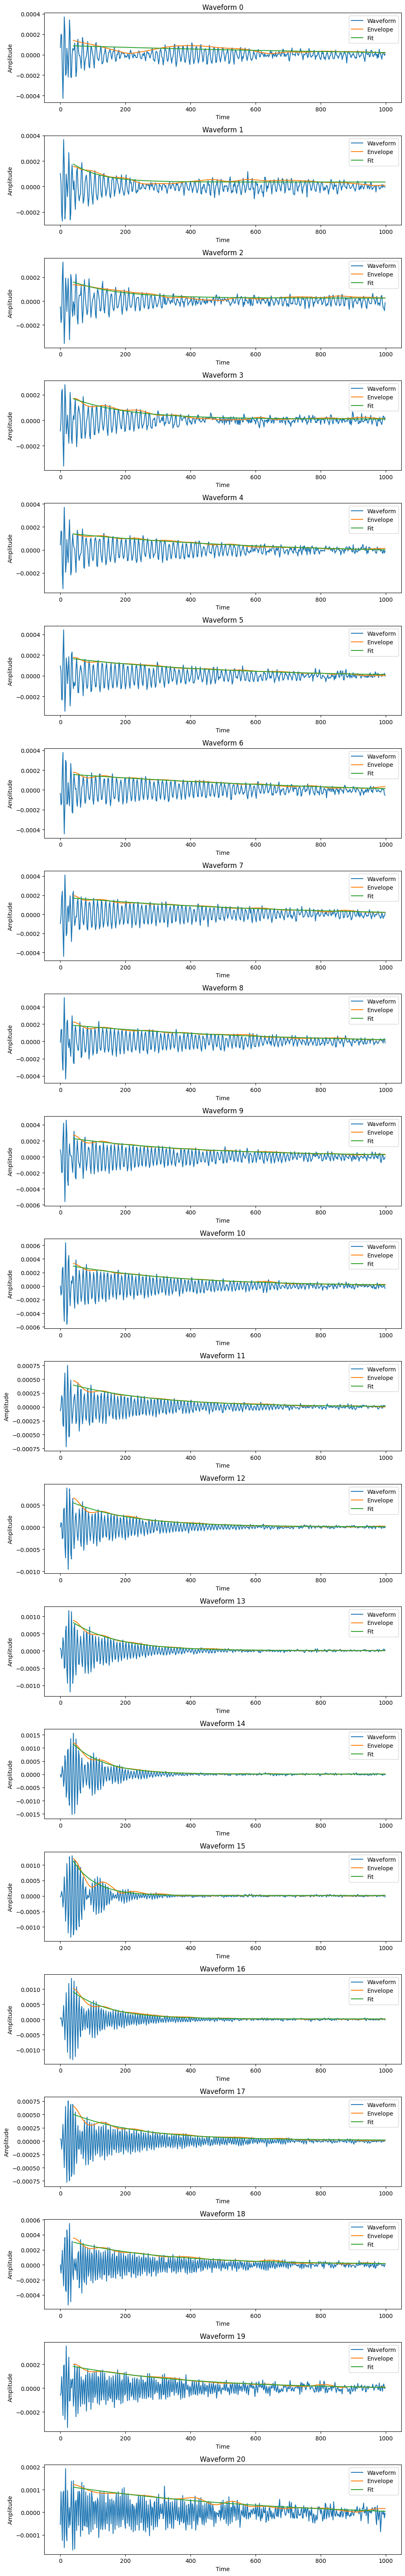

In [65]:
dataobj = WaveformAnalysisMulti(name_dict, data_path)
dataobj.generate_results(readout_lo_freq)

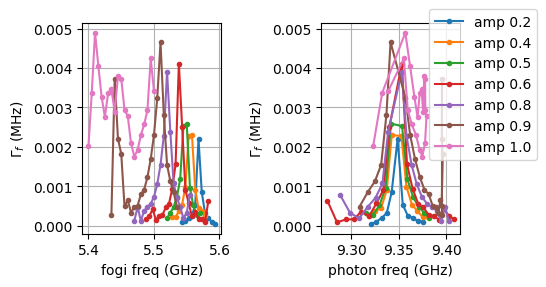

{'a0': 0, 'a2': 0.005164278377215004, 'a4': 2.83550960489265e-13, 'a6': 4.03987954200602e-12, 'a8': 1.9229062786507711e-13, 'a10': 1.2603251775544777e-12}
[1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 9.99999999e-01
 9.99999999e-01 9.99999999e-01 9.99999999e-01 9.99999999e-01
 9.99999999e-01 9.99999999e-01 9.99999999e-01 9.99999999e-01
 9.99999999e-01 9.99999999e-01 9.99999999e-01 9.99999999e-01
 9.99999999e-01 9.99999999e-01 9.99999999e-01 9.99999999e-01
 9.99999999e-01 9.99999999e-01 9.99999998e-01 9.99999998e-01
 9.99999998e-01 9.99999998e-01 9.99999998e-01 9.99999998e-01
 9.99999998e-01 9.99999998e-01 9.99999998e-01 9.99999998e-01
 9.99999997e-01 9.99999997e-01 9.99999997e-01 9.9999

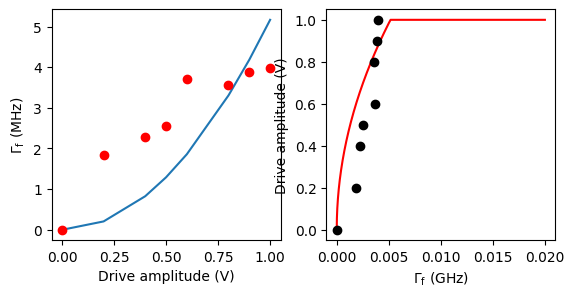

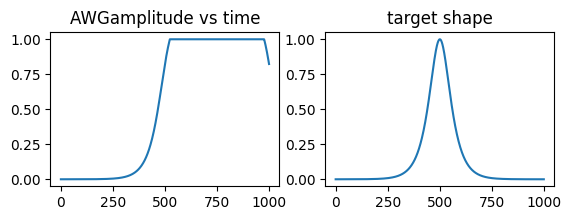

[1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 9.99999999e-01
 9.99999999e-01 9.99999999e-01 9.99999999e-01 9.99999999e-01
 9.99999999e-01 9.99999999e-01 9.99999999e-01 9.99999999e-01
 9.99999999e-01 9.99999999e-01 9.99999999e-01 9.99999999e-01
 9.99999999e-01 9.99999999e-01 9.99999999e-01 9.99999999e-01
 9.99999999e-01 9.99999999e-01 9.99999998e-01 9.99999998e-01
 9.99999998e-01 9.99999998e-01 9.99999998e-01 9.99999998e-01
 9.99999998e-01 9.99999998e-01 9.99999998e-01 9.99999998e-01
 9.99999997e-01 9.99999997e-01 9.99999997e-01 9.99999997e-01
 9.99999997e-01 9.99999997e-01 9.99999997e-01 9.99999996e-01
 9.99999996e-01 9.99999996e-01 9.99999996e-01 9.99999996e-01
 9.99999995e-01 9.999999

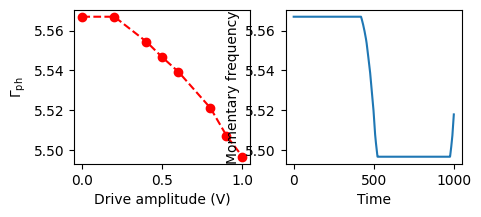

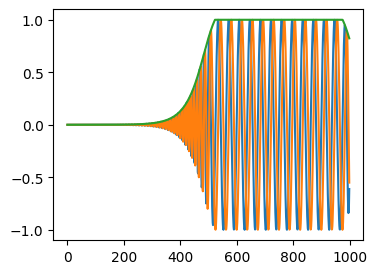

In [81]:
form = "sech_0"
const = 3.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.35

# plot decay rates
dataobj.plot_decayrates()
control_pulse = dataobj.generate_control_pulse(5.47, target_freq, duration, const=const, form=form, tr=False)[0]


## save

In [79]:
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T
forms = ["sech_0", "sech_1", "sech_2", "sech_3"] 
const = 3.5e-3*2*np.pi

for form in forms:
    for target_freq in [9.35]:
        control_pulse = dataobj.generate_control_pulse(
            5.47, target_freq, duration, const=const, form=form, plot=False, tr=False
        )[0]

        note = f"""
        form : {form}
        const : {const / 2 / np.pi}
        duration : {duration}
        target frequency : {target_freq} GHz
        """

        data = DataDict(
            time=dict(unit="ns"),
            control_pulse=dict(axes=["time"]),
        )
        data.validate()

        save_path = f"D:\\K_Sunada\\result\\control_pulses\\{cd}"

        with DDH5Writer(data, save_path, name="Control_Pulse") as writer:
            writer.add_tag(["control_pulse", cd, form])
            writer.save_text("target_shape.md", note)
            writer.add_data(
                time=np.arange(len(control_pulse)),
                control_pulse=control_pulse,
            )
        T.sleep(1)


{'a0': 0, 'a2': 0.005164278377215004, 'a4': 2.83550960489265e-13, 'a6': 4.03987954200602e-12, 'a8': 1.9229062786507711e-13, 'a10': 1.2603251775544777e-12}
[1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 9.99999999e-01
 9.99999999e-01 9.99999999e-01 9.99999999e-01 9.99999999e-01
 9.99999999e-01 9.99999999e-01 9.99999999e-01 9.99999999e-01
 9.99999999e-01 9.99999999e-01 9.99999999e-01 9.99999999e-01
 9.99999999e-01 9.99999999e-01 9.99999999e-01 9.99999999e-01
 9.99999999e-01 9.99999999e-01 9.99999998e-01 9.99999998e-01
 9.99999998e-01 9.99999998e-01 9.99999998e-01 9.99999998e-01
 9.99999998e-01 9.99999998e-01 9.99999998e-01 9.99999998e-01
 9.99999997e-01 9.99999997e-01 9.99999997e-01 9.9999

# Photon shaping analysis

In [70]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize


Form: sech_0, Symmetry: 0.40047240026835756, Overlap: 0.9506990548412799
Form: sech_1, Symmetry: 0.5395378092152507, Overlap: 0.7863290891214794
Form: sech_2, Symmetry: 0.53235495178844, Overlap: 0.6760520445443723
Form: sech_3, Symmetry: 0.4994608926613694, Overlap: 0.6472310391044093


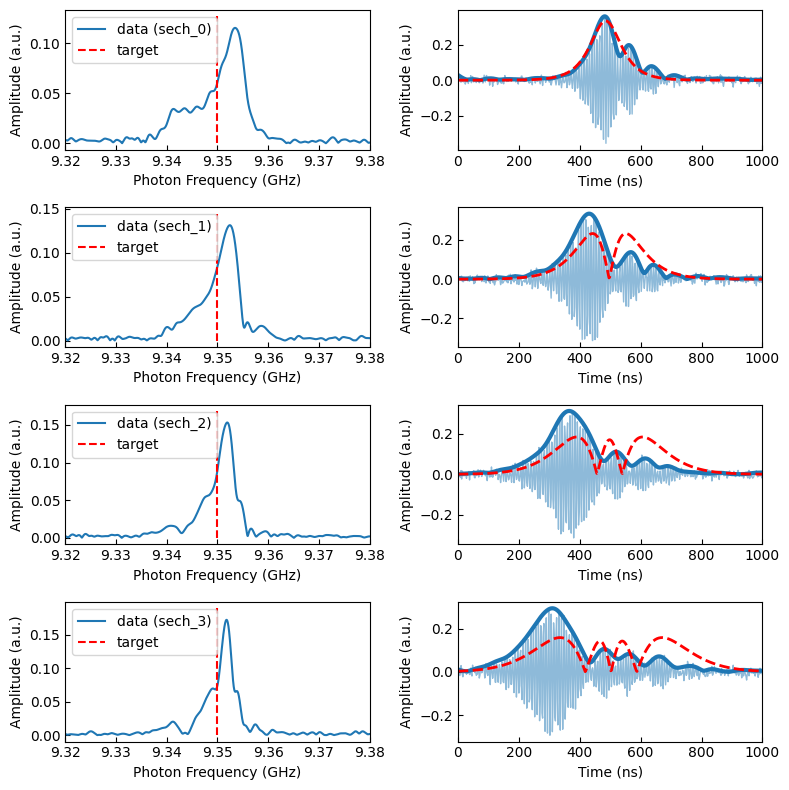

In [82]:
const = 3.5e-3*2*np.pi
passing_band = 0.01
duration = 1000
data_path = f"D:\\K_Sunada\\result\\{cd}"

result_dict = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-09", acquire_time="091448", form="sech_0"),
    "data_sech_1": dict(target_freq=9.35, date="2025-02-09", acquire_time="091602", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2025-02-09", acquire_time="091721", form="sech_2"),
    "data_sech_3": dict(target_freq=9.35, date="2025-02-09", acquire_time="091836", form="sech_3"),
}

fig, axes = plt.subplots(len(result_dict), 2, figsize=(8, 2 * len(result_dict)))

for i, (k, v) in enumerate(result_dict.items()):
    ax = axes[i, 0]
    ax2 = axes[i, 1]
    
    target_freq = v["target_freq"]
    form = v["form"]
    
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    
    ax.plot(photon_freq, 10 * np.abs(fourier), label=f"data ({form})")
    ax.vlines(target_freq, 0, 10 * max(np.abs(fourier)) * 1.1, color="r", ls="--", label="target")
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.tick_params(axis="x", direction="in")
    ax.tick_params(axis="y", direction="in")
    ax.legend()

    phase = np.angle(demodulate(time, waveform, readout_lo_freq - target_freq))
    signal = 2 * lowpass(
        time, waveform * np.exp(2j * np.pi * (readout_lo_freq - target_freq) * time),
        passing_band, 0.03, 0.1, 90
    ) * np.exp(-1j * phase)
    
    res = fit_waveform(time, np.abs(signal), curve=f"{form}", kappa=const)
    
    ax2.plot(time, 1000 * waveform, "tab:blue", lw=1, alpha=0.5)
    ax2.plot(time, 1000 * np.abs(signal), "tab:blue", lw=3, label=f"data ({form})")
    ax2.plot(time, 1000 * res, "r--", lw=2, label="target", alpha=1)
    ax2.set_xlabel("Time (ns)")
    ax2.set_ylabel("Amplitude (a.u.)")
    ax2.set_xlim(0, 1000)
    ax2.tick_params(axis="x", direction="in")
    ax2.tick_params(axis="y", direction="in")

    symmetry = IQ_sym_(signal, time)
    overlap = target_overlap(signal, time, curve=f"{form}")
    print(f"Form: {form}, Symmetry: {symmetry}, Overlap: {overlap}")

plt.tight_layout()
plt.show()


Form: sech_0, Symmetry: 0.4004360882931789, Overlap: 0.9642649305916897
Form: sech_1, Symmetry: 0.5156401111519364, Overlap: 0.7747547699405914
Form: sech_2, Symmetry: 0.413854465116078, Overlap: 0.6822074172974298
Form: sech_3, Symmetry: 0.4308071016653903, Overlap: 0.6187897483686656


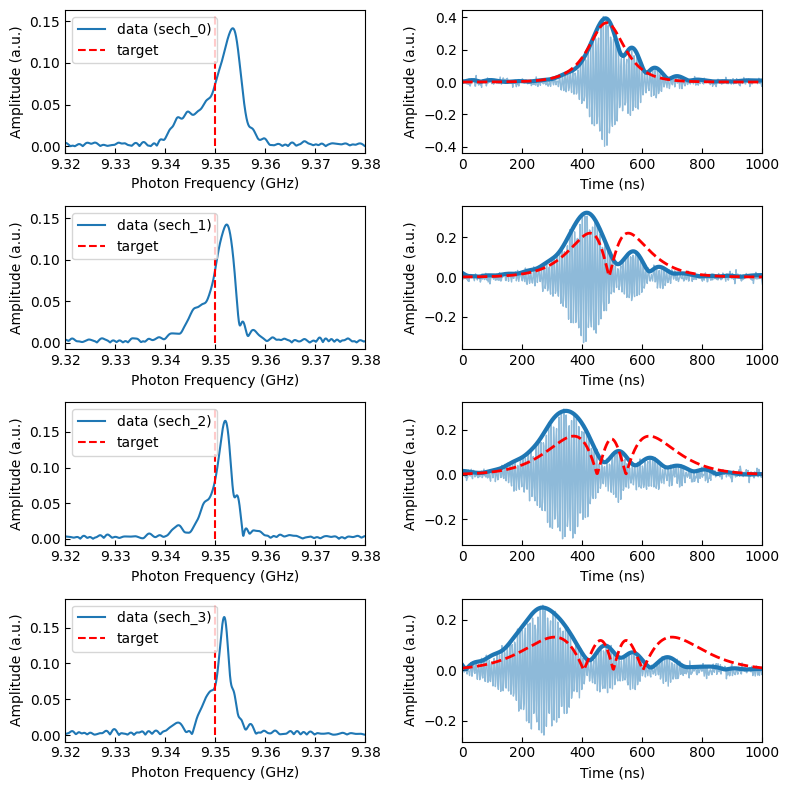

In [77]:
const = 3e-3*2*np.pi
passing_band = 0.01
duration = 1000
data_path = f"D:\\K_Sunada\\result\\{cd}"

result_dict = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-08", acquire_time="154558", form="sech_0"),
    "data_sech_1": dict(target_freq=9.35, date="2025-02-08", acquire_time="154712", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2025-02-08", acquire_time="154826", form="sech_2"),
    "data_sech_3": dict(target_freq=9.35, date="2025-02-08", acquire_time="154942", form="sech_3"),
}

fig, axes = plt.subplots(len(result_dict), 2, figsize=(8, 2 * len(result_dict)))

for i, (k, v) in enumerate(result_dict.items()):
    ax = axes[i, 0]
    ax2 = axes[i, 1]
    
    target_freq = v["target_freq"]
    form = v["form"]
    
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    
    ax.plot(photon_freq, 10 * np.abs(fourier), label=f"data ({form})")
    ax.vlines(target_freq, 0, 10 * max(np.abs(fourier)) * 1.1, color="r", ls="--", label="target")
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.tick_params(axis="x", direction="in")
    ax.tick_params(axis="y", direction="in")
    ax.legend()

    phase = np.angle(demodulate(time, waveform, readout_lo_freq - target_freq))
    signal = 2 * lowpass(
        time, waveform * np.exp(2j * np.pi * (readout_lo_freq - target_freq) * time),
        passing_band, 0.03, 0.1, 90
    ) * np.exp(-1j * phase)
    
    res = fit_waveform(time, np.abs(signal), curve=f"{form}", kappa=const)
    
    ax2.plot(time, 1000 * waveform, "tab:blue", lw=1, alpha=0.5)
    ax2.plot(time, 1000 * np.abs(signal), "tab:blue", lw=3, label=f"data ({form})")
    ax2.plot(time, 1000 * res, "r--", lw=2, label="target", alpha=1)
    ax2.set_xlabel("Time (ns)")
    ax2.set_ylabel("Amplitude (a.u.)")
    ax2.set_xlim(0, 1000)
    ax2.tick_params(axis="x", direction="in")
    ax2.tick_params(axis="y", direction="in")

    symmetry = IQ_sym_(signal, time)
    overlap = target_overlap(signal, time, curve=f"{form}")
    print(f"Form: {form}, Symmetry: {symmetry}, Overlap: {overlap}")

plt.tight_layout()
plt.show()


Form: sech_0, Symmetry: 0.45112786850476416, Overlap: 0.9833034443746176
Form: sech_1, Symmetry: 0.5355029389246079, Overlap: 0.7272190015020982
Form: sech_2, Symmetry: 0.4712626738092182, Overlap: 0.64752023498682
Form: sech_3, Symmetry: 0.3970115743425296, Overlap: 0.6122411298171052


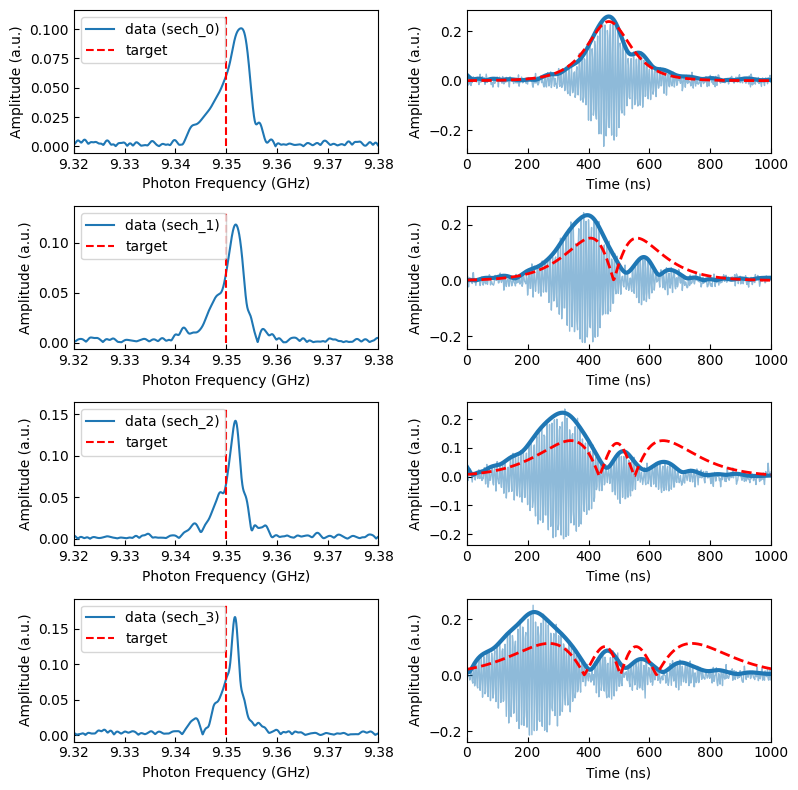

In [78]:
const = 2.5e-3*2*np.pi
passing_band = 0.01
duration = 1000
data_path = f"D:\\K_Sunada\\result\\{cd}"

result_dict = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-08", acquire_time="161406", form="sech_0"),
    "data_sech_1": dict(target_freq=9.35, date="2025-02-08", acquire_time="161520", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2025-02-08", acquire_time="161634", form="sech_2"),
    "data_sech_3": dict(target_freq=9.35, date="2025-02-08", acquire_time="161750", form="sech_3"),
}

fig, axes = plt.subplots(len(result_dict), 2, figsize=(8, 2 * len(result_dict)))

for i, (k, v) in enumerate(result_dict.items()):
    ax = axes[i, 0]
    ax2 = axes[i, 1]
    
    target_freq = v["target_freq"]
    form = v["form"]
    
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    
    ax.plot(photon_freq, 10 * np.abs(fourier), label=f"data ({form})")
    ax.vlines(target_freq, 0, 10 * max(np.abs(fourier)) * 1.1, color="r", ls="--", label="target")
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.tick_params(axis="x", direction="in")
    ax.tick_params(axis="y", direction="in")
    ax.legend()

    phase = np.angle(demodulate(time, waveform, readout_lo_freq - target_freq))
    signal = 2 * lowpass(
        time, waveform * np.exp(2j * np.pi * (readout_lo_freq - target_freq) * time),
        passing_band, 0.03, 0.1, 90
    ) * np.exp(-1j * phase)
    
    res = fit_waveform(time, np.abs(signal), curve=f"{form}", kappa=const)
    
    ax2.plot(time, 1000 * waveform, "tab:blue", lw=1, alpha=0.5)
    ax2.plot(time, 1000 * np.abs(signal), "tab:blue", lw=3, label=f"data ({form})")
    ax2.plot(time, 1000 * res, "r--", lw=2, label="target", alpha=1)
    ax2.set_xlabel("Time (ns)")
    ax2.set_ylabel("Amplitude (a.u.)")
    ax2.set_xlim(0, 1000)
    ax2.tick_params(axis="x", direction="in")
    ax2.tick_params(axis="y", direction="in")

    symmetry = IQ_sym_(signal, time)
    overlap = target_overlap(signal, time, curve=f"{form}")
    print(f"Form: {form}, Symmetry: {symmetry}, Overlap: {overlap}")

plt.tight_layout()
plt.show()


phase subtraction

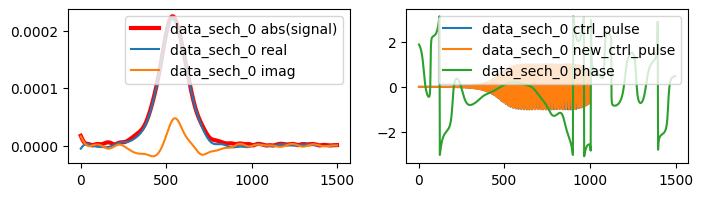

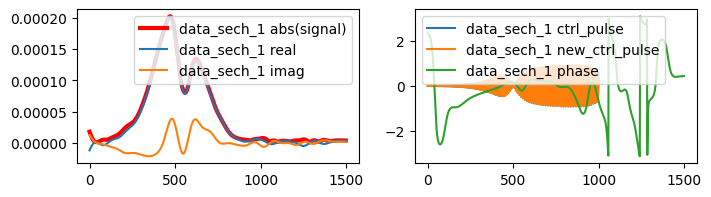

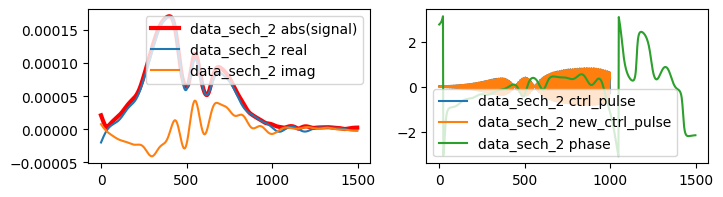

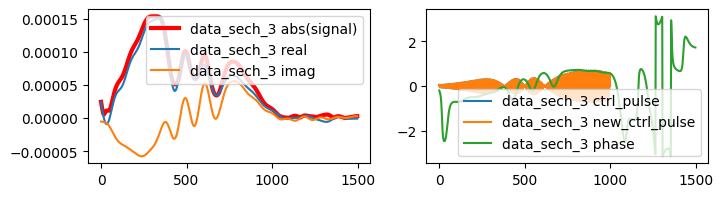

In [21]:
passing_band = 0.01
duration=1000
data_path = f"D:\\K_Sunada\\result\\{cd}"

for k, v in result_dict.items():
    fig = plt.figure(figsize=(8, 2))
    ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 2, 2)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    init_phase = np.angle(demodulate(time, waveform, readout_lo_freq - target_freq))

    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j * np.pi * (readout_lo_freq - target_freq) * time),
                        0.01, 0.03, 0.5, 90) * np.exp(-1j * init_phase)
    phase = np.angle(signal)
    
    ax.plot(time, np.abs(signal), "r-", lw=3, label=f"{k} abs(signal)")
    ax.plot(time, signal.real, label=f"{k} real")
    ax.plot(time, signal.imag, label=f"{k} imag")
    
    phase_of_time = interpolate.interp1d(time, np.unwrap(phase))

    target_shape_note = load_note(data_path, v["date"], f"{_}\\target_shape.md")
    idx = target_shape_note.find("path : ")
    ctrl_pulse_filename = target_shape_note[idx + 7:]

    _, datadict = search_datadict_miyamura(
        f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\",
        ctrl_pulse_filename[:11],
        name=ctrl_pulse_filename,
    )
    
    ctrl_pulse = datadict["control_pulse"]["values"]
    phase_for_correction = phase_of_time(np.arange(len(ctrl_pulse)))
    new_ctrl_pulse = ctrl_pulse * np.exp(1j * phase_for_correction)

    ax2.plot(ctrl_pulse.real, label=f"{k} ctrl_pulse")
    ax2.plot(new_ctrl_pulse.real, label=f"{k} new_ctrl_pulse")
    ax2.plot(time, phase, label=f"{k} phase")

    ax.legend()
    ax2.legend()

    # save
    from plottr.data.datadict_storage import DataDict, DDH5Writer
    data = DataDict(
        time=dict(unit="ns"),
        control_pulse=dict(axes=["time"]),
    )
    data.validate()

    with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\", name=f"Control_Pulse_{k}") as writer:
        writer.add_tag(["control_pulse", cd, "corrected"])
        writer.save_text("target_shape.md", "corrected \n" + target_shape_note)
        writer.add_data(
            time=np.arange(len(new_ctrl_pulse)),
            control_pulse=new_ctrl_pulse,
        )

    T.sleep(1.0)


corrected photon shaping

Form: sech_0, Symmetry: 0.8134583099202772, Overlap: 0.9950000081398452
Form: sech_1, Symmetry: 0.6874285608095594, Overlap: 0.9504976468375395
Form: sech_2, Symmetry: 0.6049755180753738, Overlap: 0.9195977842539425
Form: sech_3, Symmetry: 0.5522286863041044, Overlap: 0.9156933507977839


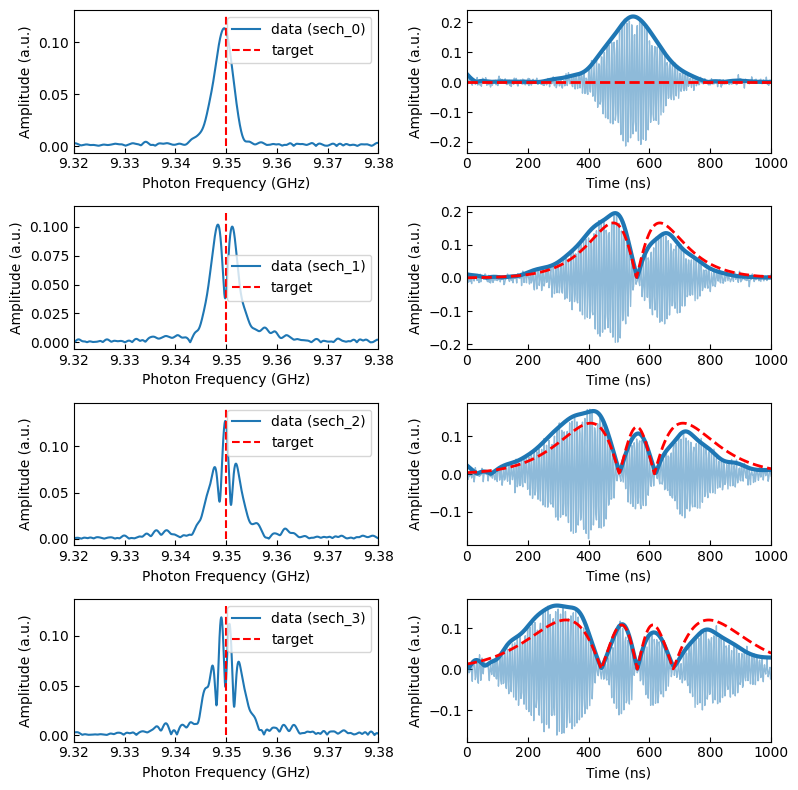

In [22]:
const = 2.5e-3 * 2 * np.pi
passing_band = 0.01
duration = 1000
data_path = f"D:\\K_Sunada\\result\\{cd}"

result_dict = {
    "data_sech_0": dict(target_freq=9.35, date="2024-11-13", acquire_time="221055", form="sech_0"),
    "data_sech_1": dict(target_freq=9.35, date="2024-11-13", acquire_time="221150", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2024-11-13", acquire_time="221242", form="sech_2"),
    "data_sech_3": dict(target_freq=9.35, date="2024-11-13", acquire_time="221334", form="sech_3"),
}

fig, axes = plt.subplots(len(result_dict), 2, figsize=(8, 2 * len(result_dict)))

for i, (k, v) in enumerate(result_dict.items()):
    ax = axes[i, 0]
    ax2 = axes[i, 1]
    
    target_freq = v["target_freq"]
    form = v["form"]
    
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    
    ax.plot(photon_freq, 10 * np.abs(fourier), label=f"data ({form})")
    ax.vlines(target_freq, 0, 10 * max(np.abs(fourier)) * 1.1, color="r", ls="--", label="target")
    ax.set_xlim(9.32, 9.38)
    ax.set_xlabel("Photon Frequency (GHz)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.tick_params(axis="x", direction="in")
    ax.tick_params(axis="y", direction="in")
    ax.legend()

    phase = np.angle(demodulate(time, waveform, readout_lo_freq - target_freq))
    signal = 2 * lowpass(
        time, waveform * np.exp(2j * np.pi * (readout_lo_freq - target_freq) * time),
        passing_band, 0.03, 0.1, 90
    ) * np.exp(-1j * phase)
    
    res = fit_waveform(time, np.abs(signal), curve=f"{form}", kappa=const)
    
    ax2.plot(time, 1000 * waveform, "tab:blue", lw=1, alpha=0.5)
    ax2.plot(time, 1000 * np.abs(signal), "tab:blue", lw=3, label=f"data ({form})")
    ax2.plot(time, 1000 * res, "r--", lw=2, label="target", alpha=1)
    ax2.set_xlabel("Time (ns)")
    ax2.set_ylabel("Amplitude (a.u.)")
    ax2.set_xlim(0, 1000)
    ax2.tick_params(axis="x", direction="in")
    ax2.tick_params(axis="y", direction="in")

    symmetry = IQ_sym_(signal, time)
    overlap = target_overlap(signal, time, curve=f"{form}")
    print(f"Form: {form}, Symmetry: {symmetry}, Overlap: {overlap}")

plt.tight_layout()
plt.show()


fogi pulse generation for absoption

In [ ]:
# control_pulse
date = "2024-10-13"
acquire_time="210009"

_, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date, acquire_time=acquire_time)
ctrl_pulse = datadict["control_pulse"]["values"]
phase = np.unwrap(np.angle(ctrl_pulse))
env = np.abs(ctrl_pulse)
env_rvs = np.flip(env)
phase_rvs = np.flip(phase)
inst_omega_minus = -np.diff(phase_rvs)
phase_recieve = np.zeros(phase.shape)
for i in range(1, len(phase_recieve)):
    phase_recieve[i] = phase_recieve[i-1] + inst_omega_minus[i-1]
recieve_pulse = env_rvs * np.exp(1j * phase_recieve)
target_shape_note = load_note(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date,
                                f"{_}\\target_shape.md") + f"\nRecieveVersion of {_}"

from plottr.data.datadict_storage import DataDict, DDH5Writer
data = DataDict(
    time=dict(unit="ns"),
    control_pulse=dict(axes=["time"]),
)
data.validate()

with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Recieve_Pulse") as writer:
    writer.add_tag(["recieve_pulse", cd,])
    writer.save_text("target_shape.md", target_shape_note)
    writer.add_data(
        time=np.arange(len(recieve_pulse)),
        control_pulse=recieve_pulse,
    )

In [ ]:
def find_zero_point(envelope):
    diff_envelope = np.diff(envelope)
    inflection_points = np.where(np.diff(np.sign(diff_envelope)))[0]
    
    return inflection_points

{'a0': 0, 'a2': 0.004173189236026609, 'a4': 8.241407556397462e-12, 'a6': 2.0472512574087887e-13, 'a8': 5.198064201294983e-13, 'a10': 4.893641047942765e-12}
[433 498 604 981]


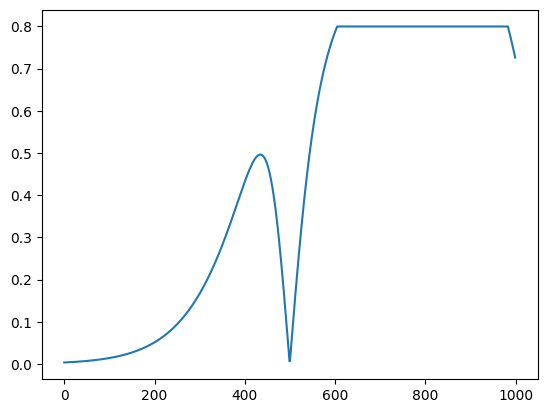

In [ ]:
control_envelope = dataobj.generate_control_pulse(5.5, 9.35, duration, const=const, form=form, plot=False, tr=False)[1]
print(find_zero_point(control_envelope))
plt.plot(control_envelope)

receive

In [ ]:
date = "2024-10-13"
acquire_time="210234"

_, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date, acquire_time=acquire_time)
ctrl_pulse = datadict["control_pulse"]["values"]
phase = np.unwrap(np.angle(ctrl_pulse))
env = np.abs(ctrl_pulse)
env_rvs = np.flip(env)
phase_rvs = np.flip(phase)
inst_omega_minus = -np.diff(phase_rvs)
phase_recieve = np.zeros(phase.shape)
for i in range(1, len(phase_recieve)):
    phase_recieve[i] = phase_recieve[i-1] + inst_omega_minus[i-1]
for i in range(int(len(env_rvs)/2), len(env_rvs)):
    env_rvs[i] = -env_rvs[i]
recieve_pulse = env_rvs * np.exp(1j * phase_recieve)
target_shape_note = load_note(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date,
                                f"{_}\\target_shape.md") + f"\nRecieveVersion of {_}"

from plottr.data.datadict_storage import DataDict, DDH5Writer
data = DataDict(
    time=dict(unit="ns"),
    control_pulse=dict(axes=["time"]),
)
data.validate()

with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Recieve_Pulse") as writer:
    writer.add_tag(["recieve_pulse_othogonal", cd,])
    writer.save_text("target_shape.md", target_shape_note)
    writer.add_data(
        time=np.arange(len(recieve_pulse)),
        control_pulse=recieve_pulse,
    )

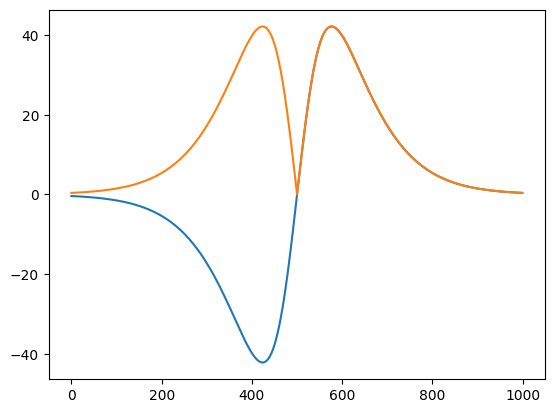

In [ ]:
fogi_duration = 1000
ph_if = readout_lo_freq*1e9 - 10.3875*1e9
x = np.linspace(0, 999, 1000)
const = 2.5e-3 * 2 * np.pi
ph_waveform =(x - fogi_duration/2)/np.cosh(const * (x - fogi_duration/2))#*np.cos(2*np.pi* ph_if*x*1e-9) #1/np.cosh(const * (x - fogi_duration/2))*np.cos(2*np.pi* ph_if*x*1e-9) 

plt.plot(x, ph_waveform)
plt.plot(x, np.abs(ph_waveform))

In [ ]:
def find_zero_point(envelope):
    diff_envelope = np.diff(envelope)
    inflection_points = np.where(np.diff(np.sign(diff_envelope)))[0]
    
    return inflection_points

{'a0': 0, 'a2': 0.002430594400620878, 'a4': 6.6564531664425886e-12, 'a6': 1.0058620603103918e-12, 'a8': 2.8630431359033537e-12, 'a10': 7.817080316385727e-12}
[359 441 501 556 674 994]
1000


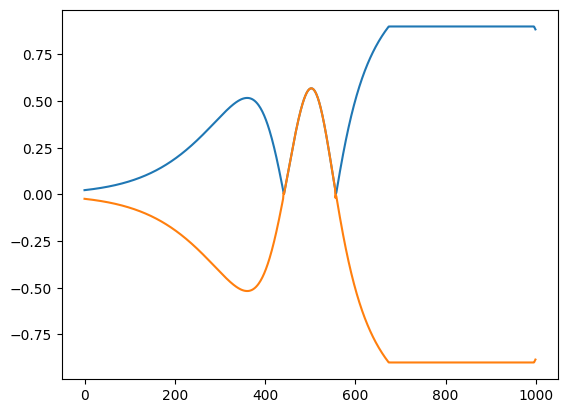

In [ ]:
import itertools
control_envelope = dataobj.generate_control_pulse(5.5, 9.35, duration, const=const, form=form, plot=False, tr=False)[1]
print(find_zero_point(control_envelope))
plt.plot(control_envelope)

# for i in range(len(control_envelope)):
#     control_envelope[i] = -control_envelope[i]
for i in itertools.chain(range(0, 441), range(556, len(control_envelope))):
    control_envelope[i] = -control_envelope[i]
plt.plot(control_envelope)
print(len(control_envelope))

In [59]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import interpolate, optimize

const = 2.5e-3 * 2 * np.pi
result_dict = dict(
    # data0 = dict(target_freq=9.33, date="2024-09-22", acquire_time="182617"),
    data1 = dict(target_freq=9.35, date="2024-11-13", acquire_time="221242"),
    # data2 = dict(target_freq=9.37, date="2024-09-22", acquire_time="183956"),
)

receive

In [ ]:
date = "2024-10-13"
acquire_time="210304"

_, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date, acquire_time=acquire_time)
ctrl_pulse = datadict["control_pulse"]["values"]
phase = np.unwrap(np.angle(ctrl_pulse))
env = np.abs(ctrl_pulse)
env_rvs = np.flip(env)
phase_rvs = np.flip(phase)
inst_omega_minus = -np.diff(phase_rvs)
phase_recieve = np.zeros(phase.shape)
for i in range(1, len(phase_recieve)):
    phase_recieve[i] = phase_recieve[i-1] + inst_omega_minus[i-1]
for i in range(442, 557):
    env_rvs[i] = -env_rvs[i]
recieve_pulse = env_rvs * np.exp(1j * phase_recieve)
target_shape_note = load_note(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date,
                                f"{_}\\target_shape.md") + f"\nRecieveVersion of {_}"

from plottr.data.datadict_storage import DataDict, DDH5Writer
data = DataDict(
    time=dict(unit="ns"),
    control_pulse=dict(axes=["time"]),
)
data.validate()

with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Recieve_Pulse") as writer:
    writer.add_tag(["recieve_pulse_othogonal", cd,])
    writer.save_text("target_shape.md", target_shape_note)
    writer.add_data(
        time=np.arange(len(recieve_pulse)),
        control_pulse=recieve_pulse,
    )

In [ ]:
def find_zero_point(envelope):
    diff_envelope = np.diff(envelope)
    inflection_points = np.where(np.diff(np.sign(diff_envelope)))[0]
    
    return inflection_points

{'a0': 0, 'a2': 0.004173189236026609, 'a4': 8.241407556397462e-12, 'a6': 2.0472512574087887e-13, 'a8': 5.198064201294983e-13, 'a10': 4.893641047942765e-12}
[277 380 449 498 552 617 890]


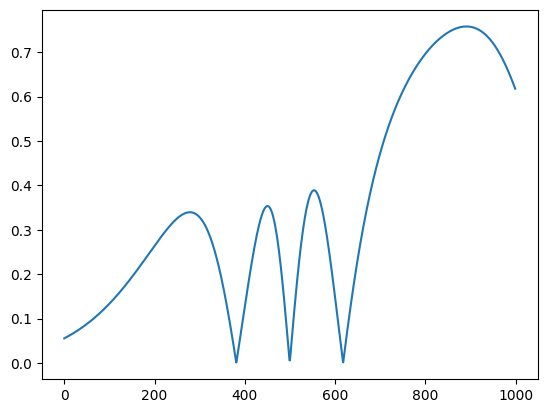

In [ ]:
control_envelope = dataobj.generate_control_pulse(5.5, 9.35, duration, const=const, form=form, plot=False, tr=False)[1]
print(find_zero_point(control_envelope))
plt.plot(control_envelope)

receive

In [ ]:
date = "2024-10-13"
acquire_time="210343"

_, datadict = search_datadict_miyamura(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date, acquire_time=acquire_time)
ctrl_pulse = datadict["control_pulse"]["values"]
phase = np.unwrap(np.angle(ctrl_pulse))
env = np.abs(ctrl_pulse)
env_rvs = np.flip(env)
phase_rvs = np.flip(phase)
inst_omega_minus = -np.diff(phase_rvs)
phase_recieve = np.zeros(phase.shape)
for i in range(1, len(phase_recieve)):
    phase_recieve[i] = phase_recieve[i-1] + inst_omega_minus[i-1]
for i in itertools.chain(range(381, 500), range(618, len(env_rvs))):
    env_rvs[i] = -env_rvs[i]
recieve_pulse = env_rvs * np.exp(1j * phase_recieve)
target_shape_note = load_note(f"D:\\K_Sunada\\result\\control_pulses\\{cd}", date,
                                f"{_}\\target_shape.md") + f"\nRecieveVersion of {_}"

from plottr.data.datadict_storage import DataDict, DDH5Writer
data = DataDict(
    time=dict(unit="ns"),
    control_pulse=dict(axes=["time"]),
)
data.validate()

with DDH5Writer(data, f"D:\\K_Sunada\\result\\control_pulses\\{cd}", name="Recieve_Pulse") as writer:
    writer.add_tag(["recieve_pulse_othogonal", cd,])
    writer.save_text("target_shape.md", target_shape_note)
    writer.add_data(
        time=np.arange(len(recieve_pulse)),
        control_pulse=recieve_pulse,
    )

In [80]:
pulse_dict_tx = dict(
    data0 = dict(target_freq=9.35, date="2024-11-13", acquire_time="215847"),
    data1 = dict(target_freq=9.35, date="2024-11-13", acquire_time="220024"),
    data2 = dict(target_freq=9.35, date="2024-11-13", acquire_time="220828"),
    data3 = dict(target_freq=9.35, date="2024-11-13", acquire_time="221021"),
)
pulse_dict_rx = dict(
    data0 = dict(target_freq=9.35, date="2024-11-13", acquire_time="224118"),
    data1 = dict(target_freq=9.35, date="2024-11-13", acquire_time="224219"),
    data2 = dict(target_freq=9.35, date="2024-11-13", acquire_time="224310"),
    data3 = dict(target_freq=9.35, date="2024-11-13", acquire_time="224433"),
)

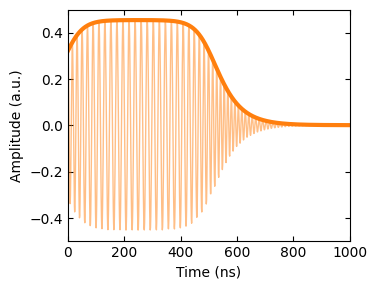

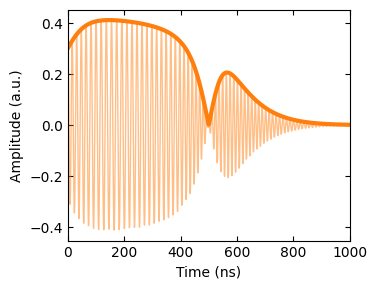

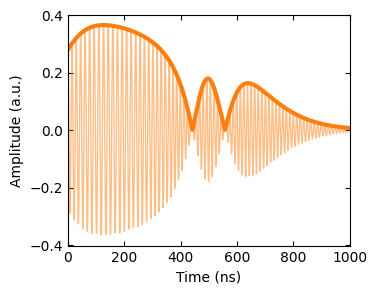

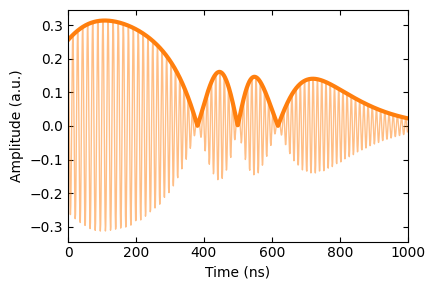

In [88]:
passing_band = 0.01
duration=1000
data_path = f"D:\\K_Sunada\\result\\control_pulses\\{cd}"

for k, v in pulse_dict_rx.items():
    fig = plt.figure(figsize=(8, 3))
    ax = fig.add_subplot(1, 2, 1)
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"]#.ravel()
    waveform = datadict["control_pulse"]["values"]#.ravel()
    # print(time, waveform)

    ax.plot(time, waveform.real, "tab:orange", lw=1, alpha=0.5)
    ax.plot(time, np.abs(waveform), "tab:orange",  lw=3, label="data")
    ax.set_xlabel("Time (ns)")
    ax.set_ylabel("Amplitude (a.u.)")
    ax.set_xlim(0, 1000)
    ax.tick_params(axis="x", direction="in")
    ax.tick_params(axis="y", direction="in")
    ax.tick_params(top='on',bottom='on',left='on',right='on',)
    # print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='sech_3')}")
# plt.legend/)
plt.tight_layout()
plt.show()